In [2]:
#pip install pandas numpy matplotlib seaborn scikit-learn nltk transformers torch shap xgboost lightgbm catboost 

#### Load Datasets

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for better looking charts
sns.set_theme(style="whitegrid")

# Load the datasets
musicians_df = pd.read_csv('Dataset/musicians.csv')
clients_df = pd.read_csv('Dataset/clients.csv')
events_df = pd.read_csv('Dataset/events.csv')
bookings_df = pd.read_csv('Dataset/bookings.csv')
reviews_df = pd.read_csv('Dataset/reviews.csv')
print("Data successfully loaded!")
print(f"Total Musicians: {len(musicians_df)}")
print(f"Total Bookings: {len(bookings_df)}")

Data successfully loaded!
Total Musicians: 300
Total Bookings: 200


#### Handle Missing Values

In [16]:
# Convert date columns to datetime objects
events_df['Date_Time'] = pd.to_datetime(events_df['Date_Time'])
bookings_df['Date_Time'] = pd.to_datetime(bookings_df['Date_Time'])
reviews_df['Created_At'] = pd.to_datetime(reviews_df['Created_At'])

# Check for missing values in critical columns
print("\nMissing values in Bookings:")
print(bookings_df.isnull().sum())

# Fill missing numerical values with the median
if bookings_df['Price_Charged'].isnull().any():
    bookings_df['Price_Charged'].fillna(bookings_df['Price_Charged'].median(), inplace=True)


Missing values in Bookings:
Booking_ID       0
Musician_ID      0
Client_ID        0
Event_ID         0
Date_Time        0
Duration         0
Price_Charged    0
Rating           0
dtype: int64


#### Merge Dataset

In [17]:
# Merge Bookings with Event details
master_df = bookings_df.merge(events_df, on='Event_ID', how='left', suffixes=('_booking', '_event'))

# Merge the result with Musician details
master_df = master_df.merge(musicians_df, on='Musician_ID', how='left')

# Display the first few rows to confirm the merge
master_df.head()

,Booking_ID,Musician_ID,Client_ID_booking,Event_ID,Date_Time_booking,Duration,Price_Charged,Rating,Client_ID_event,City,...,Event_Type,Budget,Musician_Name,Musician_Type,Musician_Contact,Location,Genres,Years_Experience,Base_Price,Social_Links
0,B001,M028,C012,E001,2025-01-11 19:30:00,3,6000,5,C096,London,...,Corporate,15350,London Philharmonic Ensemble,Band,bookings@lpe.co.uk,London,Classical,20,2000,True
1,B002,M004,C002,E002,2025-01-17 21:00:00,2,1600,4,C070,London,...,Corporate,6200,Brass & Copper,Band,hello@brassandcopper.com,Bristol,"Jazz, Soul",8,800,True
2,B003,M006,C040,E003,2025-01-24 18:00:00,4,4800,5,C006,Cardiff,...,Pub Gig,500,The Velvet Strings,Quartet,events@velvetstrings.co.uk,Edinburgh,Classical,15,1200,True
3,B004,M010,C014,E004,2025-01-31 20:30:00,3,1500,5,C035,Glasgow,...,Corporate,13700,Arthur Pendelton,Solo,arthurpiano@keys.com,Manchester,Classical,20,500,True
4,B005,M001,C005,E005,2025-02-08 14:00:00,2,900,4,C073,Glasgow,...,Corporate,6400,The Midnight Echoes,Band,booking@midnightechoes.co.uk,London,"Indie, Rock",5,450,True


#### EDA

/var/folders/xy/705xk1ln5v7f74p7pcfgn9hr0000gn/T/ipykernel_11082/686082327.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='Event_Type', y='Price_Charged', estimator=np.mean, errorbar=None, palette='viridis')
/var/folders/xy/705xk1ln5v7f74p7pcfgn9hr0000gn/T/ipykernel_11082/686082327.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='Rating', palette='magma')


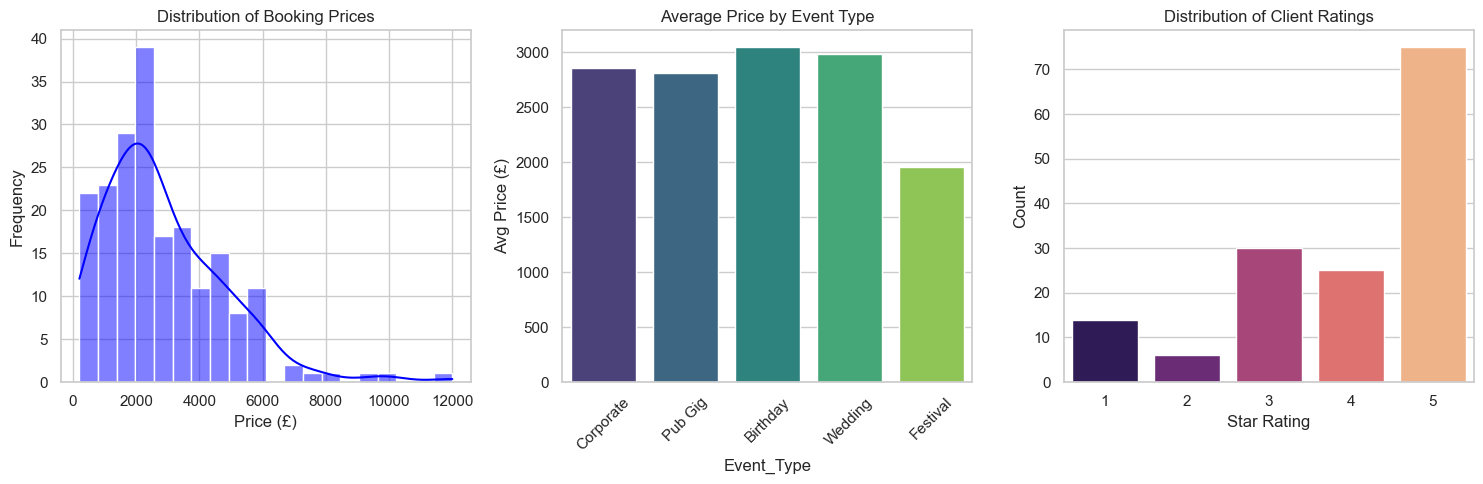

In [18]:
plt.figure(figsize=(15, 5))

# Chart 1: Distribution of Prices Charged
plt.subplot(1, 3, 1)
sns.histplot(master_df['Price_Charged'], bins=20, kde=True, color='blue')
plt.title('Distribution of Booking Prices')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

# Chart 2: Average Price by Event Type
plt.subplot(1, 3, 2)
sns.barplot(data=master_df, x='Event_Type', y='Price_Charged', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Price by Event Type')
plt.xticks(rotation=45)
plt.ylabel('Avg Price (£)')

# Chart 3: Distribution of Review Ratings
plt.subplot(1, 3, 3)
sns.countplot(data=reviews_df, x='Rating', palette='magma')
plt.title('Distribution of Client Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# VADER - Review Sentiment Analysis

In [19]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Download the VADER lexicon
nltk.download('vader_lexicon')

# Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to the Review_Text column
reviews_df['VADER_Scores'] = reviews_df['Review_Text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract the compound score (ranges from -1 to 1)
reviews_df['VADER_Compound'] = reviews_df['VADER_Scores'].apply(lambda d: d['compound'])

# Classify based on the compound score
reviews_df['VADER_Label'] = reviews_df['VADER_Compound'].apply(
    lambda score: 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
)

print(reviews_df[['Review_Text', 'VADER_Compound', 'VADER_Label']].head())

                                         Review_Text  VADER_Compound  \
0  Absolutely amazing! Very punctual and the soun...          0.8436   
1  Great crowd engagement. They really knew how t...          0.8750   
2  Top notch performance. Punctual and profession...          0.2023   
3  The sound quality blew us away. Incredible att...          0.5413   
4  Amazing crowd engagement. Everyone was on the ...          0.7783   

  VADER_Label  
0    Positive  
1    Positive  
2    Positive  
3    Positive  
4    Positive  


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/demikadesilva/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


#### Evaluation Of VADER

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Binary mapping
reviews_df['True_Binary'] = reviews_df['True_Label'].map({'Positive':1, 'Negative':0})
reviews_df['VADER_Binary'] = reviews_df['VADER_Label'].map({'Positive':1, 'Negative':0})

eval_df = reviews_df.dropna(subset=['True_Binary','VADER_Binary'])

precision = precision_score(eval_df['True_Binary'], eval_df['VADER_Binary'])
recall = recall_score(eval_df['True_Binary'], eval_df['VADER_Binary'])
f1 = f1_score(eval_df['True_Binary'], eval_df['VADER_Binary'])

print("VADER Evaluation Metrics")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))

print("\nDetailed Report:")
print(classification_report(eval_df['True_Binary'], eval_df['VADER_Binary']))

VADER Evaluation Metrics
Precision: 0.969
Recall: 0.939
F1 Score: 0.954

Detailed Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        15
           1       0.97      0.94      0.95        99

    accuracy                           0.92       114
   macro avg       0.82      0.87      0.84       114
weighted avg       0.93      0.92      0.92       114



# BERT - Review Sentiment Analysis

In [28]:
from transformers import pipeline

# Load a pre trained BERT model for sentiment analysis (DistilBERT)
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_bert_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        score = result['score'] if result['label'] == 'POSITIVE' else -result['score']
        label = 'Positive' if result['label'] == 'POSITIVE' else 'Negative'
        return pd.Series([score, label])
    except Exception as e:
        return pd.Series([0.0, 'Neutral'])

# Apply the BERT model
reviews_df[['BERT_Score', 'BERT_Label']] = reviews_df['Review_Text'].apply(get_bert_sentiment)

print(reviews_df[['Review_Text', 'VADER_Label', 'BERT_Label']].head())

Device set to use mps:0


                                         Review_Text VADER_Label BERT_Label
0  Absolutely amazing! Very punctual and the soun...    Positive   Positive
1  Great crowd engagement. They really knew how t...    Positive   Positive
2  Top notch performance. Punctual and profession...    Positive   Positive
3  The sound quality blew us away. Incredible att...    Positive   Positive
4  Amazing crowd engagement. Everyone was on the ...    Positive   Positive


#### Evaluation for BERT

In [40]:
from sklearn.metrics import accuracy_score, classification_report

def get_true_label(rating):
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['True_Label'] = reviews_df['Rating'].apply(get_true_label)

eval_df = reviews_df[reviews_df['True_Label'] != 'Neutral'].copy()

vader_accuracy = accuracy_score(eval_df['True_Label'], eval_df['VADER_Label'])
bert_accuracy = accuracy_score(eval_df['True_Label'], eval_df['BERT_Label'])

print("--- MODEL ACCURACY COMPARISON ---")
print(f"VADER (Rule-Based) Accuracy: {vader_accuracy * 100:.2f}%")
print(f"BERT (Transformer) Accuracy:   {bert_accuracy * 100:.2f}%\n")

print("--- VADER CLASSIFICATION REPORT ---")
print(classification_report(eval_df['True_Label'], eval_df['VADER_Label'], zero_division=0))

print("--- BERT CLASSIFICATION REPORT ---")
print(classification_report(eval_df['True_Label'], eval_df['BERT_Label'], zero_division=0))

disagreements = eval_df[(eval_df['BERT_Label'] == eval_df['True_Label']) & 
                        (eval_df['VADER_Label'] != eval_df['True_Label'])]

if not disagreements.empty:
    print("--- EXAMPLE WHERE BERT OUTPERFORMED VADER ---")
    example = disagreements.iloc[0]
    print(f"Review Text: '{example['Review_Text']}'")
    print(f"Ground Truth (from Rating): {example['True_Label']}")
    print(f"VADER Guessed: {example['VADER_Label']} (Score: {example['VADER_Compound']})")
    print(f"BERT Guessed:  {example['BERT_Label']} (Score: {example['BERT_Score']})")

--- MODEL ACCURACY COMPARISON ---
VADER (Rule-Based) Accuracy: 87.50%
BERT (Transformer) Accuracy:   91.67%

--- VADER CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Negative       0.67      0.60      0.63        20
     Neutral       0.00      0.00      0.00         0
    Positive       0.97      0.93      0.95       100

    accuracy                           0.88       120
   macro avg       0.55      0.51      0.53       120
weighted avg       0.92      0.88      0.90       120

--- BERT CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Negative       0.71      0.85      0.77        20
    Positive       0.97      0.93      0.95       100

    accuracy                           0.92       120
   macro avg       0.84      0.89      0.86       120
weighted avg       0.93      0.92      0.92       120

--- EXAMPLE WHERE BERT OUTPERFORMED VADER ---
Review Text: 'Not punctual at all. Ruined the schedule and had zer

DistilBERT F1 Score: 0.954


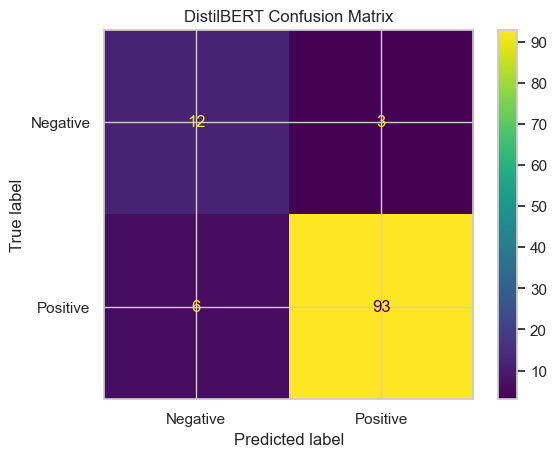

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

f1_bert = f1_score(eval_df['True_Binary'], eval_df['BERT_Binary'])
print("DistilBERT F1 Score:", round(f1_bert,3))

cm = confusion_matrix(eval_df['True_Binary'], eval_df['BERT_Binary'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Positive"])
disp.plot()
plt.title("DistilBERT Confusion Matrix")
plt.show()

# Anomaly Detection - Fake Reviews

In [31]:
from sklearn.ensemble import IsolationForest
import numpy as np

# basic metadata features to feed the Isolation Forest
# 1. Text length
reviews_df['Review_Length'] = reviews_df['Review_Text'].apply(lambda x: len(str(x)))

# 2. Rating contrast
reviews_df['Sentiment_Rating_Gap'] = abs(reviews_df['Rating'] - ((reviews_df['VADER_Compound'] + 1) * 2.5))

# Prepare features for the model
anomaly_features = reviews_df[['Rating', 'Review_Length', 'Sentiment_Rating_Gap']].fillna(0)

# Initialize and fit the Isolation Forest
iso_forest = IsolationForest(contamination=0.10, random_state=42)
reviews_df['Is_Anomaly'] = iso_forest.fit_predict(anomaly_features)

reviews_df['Review_Status'] = reviews_df['Is_Anomaly'].map({-1: 'Flagged', 1: 'Verified'})

print("Anomaly Detection Results:")
print(reviews_df['Review_Status'].value_counts())

Anomaly Detection Results:
Review_Status
Verified    109
Flagged      11
Name: count, dtype: int64


#### Anomaly Score Distribution

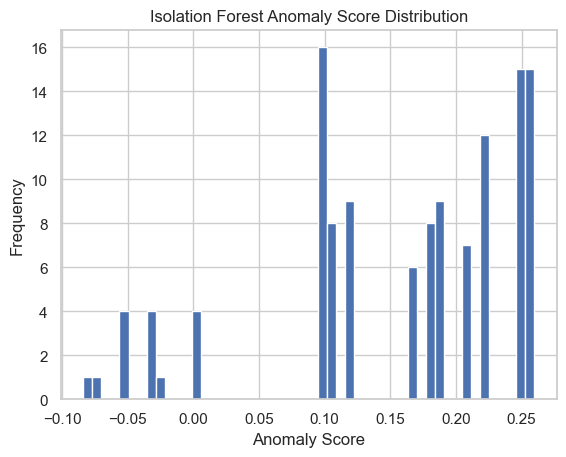

In [32]:
# Get anomaly scores
reviews_df['Anomaly_Score'] = iso_forest.decision_function(anomaly_features)

import matplotlib.pyplot as plt

plt.hist(reviews_df['Anomaly_Score'], bins=50)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

# Content Based Filtering - Recommendation (Cold Start) 

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

musicians_df['Profile'] = musicians_df['Genres'].fillna('') + " " + \
                            musicians_df['Location'].fillna('') + " " + \
                            musicians_df['Musician_Type'].fillna('')

# Initialize the TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the musician profiles into a mathematical matrix
musician_matrix = tfidf.fit_transform(musicians_df['Profile'])

# 2. Build the Content-Based Recommendation Function
def get_cbf_recommendations(target_genre, target_location, target_type, top_n=5):
    """
    Simulates a new user searching for a gig.
    Matches their search criteria against the musician profiles.
    """
    # Combine the user's search criteria into a single string
    query = f"{target_genre} {target_location} {target_type}"

    # Vectorize the user's query
    query_vector = tfidf.transform([query])

    # Calculate Cosine Similarity between the query and all musicians
    cosine_sim = cosine_similarity(query_vector, musician_matrix).flatten()

    # Get the indices of the top matches
    top_indices = cosine_sim.argsort()[-top_n:][::-1]

    # Retrieve the top musicians and their similarity scores
    results = musicians_df.iloc[top_indices].copy()
    results['Similarity_Score'] = cosine_sim[top_indices]

    return results[['Musician_Name', 'Genres', 'Location', 'Musician_Type', 'Similarity_Score']]

# Let's test it! Simulating a cold-start user looking for an Indie Rock band in London.
print("Cold-Start Recommendations (Indie Rock, London, Band):")
test_recs = get_cbf_recommendations(target_genre="Indie Rock", target_location="London", target_type="Band")
print(test_recs)

Cold-Start Recommendations (Indie Rock, London, Band):
           Musician_Name       Genres Location Musician_Type  Similarity_Score
0    The Midnight Echoes  Indie, Rock   London          Band          1.000000
156     Mrs Amy Anderson  Indie, Rock   London          Solo          0.820602
46            Sonic Boom  Indie, Rock  Bristol          Band          0.726486
89        The Modfathers  Indie, Rock  Glasgow          Band          0.712470
42            Nightshift    Pop, Rock   London          Band          0.701919


#### Binary Relevance

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_cbf(client_id, target_genre, target_location, target_type):
    
    recommendations = get_cbf_recommendations(target_genre, target_location, target_type, top_n=10)
    recommended_ids = musicians_df.loc[recommendations.index, 'Musician_ID']
    
    relevant_ids = bookings_df[bookings_df['Client_ID']==client_id]['Musician_ID'].unique()
    
    y_true = [1 if mid in relevant_ids else 0 for mid in recommended_ids]
    y_pred = [1]*len(recommended_ids)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    
    print("CBF Evaluation")
    print("Accuracy:", round(accuracy,3))
    print("Precision:", round(precision,3))
    print("Recall:", round(recall,3))
    print("F1 Score:", round(f1,3))

# Example
evaluate_cbf(test_client, "Rock", "London", "Band")

CBF Evaluation
Accuracy: 0.1
Precision: 0.1
Recall: 1.0
F1 Score: 0.182


# Hybrid Filtering - Recommendation

In [35]:
from sklearn.decomposition import TruncatedSVD

# Create a User-Item Interaction Matrix using Client ratings for Musicians
user_item_matrix = bookings_df.pivot_table(index='Client_ID', columns='Musician_ID', values='Rating', fill_value=0)

# Apply Truncated SVD to factorize the matrix 
n_components = min(20, user_item_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
matrix_factorized = svd.fit_transform(user_item_matrix)

# Reconstruct the predicted ratings matrix
predicted_ratings = np.dot(matrix_factorized, svd.components_)
predicted_ratings_df = pd.DataFrame(predicted_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

def get_cf_predictions(client_id):
    """Returns CF predictions for a specific client."""
    if client_id in predicted_ratings_df.index:
        # Scale to 0-1 for easy hybrid blending
        preds = predicted_ratings_df.loc[client_id]
        if preds.max() > 0:
            return preds / preds.max()
        return preds
    return pd.Series(dtype=float)


# PREPARING THE SENTIMENT MULTIPLIER
review_booking_link = reviews_df.merge(bookings_df[['Booking_ID', 'Musician_ID']], on='Booking_ID', how='inner')

# Calculate the average BERT sentiment score for each musician
valid_reviews = review_booking_link[review_booking_link['Review_Status'] == 'Verified']
musician_sentiment = valid_reviews.groupby('Musician_ID')['BERT_Score'].mean().reset_index()

# Merge this back into our main musicians_df
musicians_df = musicians_df.merge(musician_sentiment, on='Musician_ID', how='left')

musicians_df['BERT_Score'] = musicians_df['BERT_Score'].fillna(0.0)


# THE ADAPTIVE HYBRID SYSTEM WITH SENTIMENT
def get_hybrid_recommendations(client_id, target_genre, target_location, target_type, beta=0.2):
    """
    Blends CBF and CF based on user history, then applies the Sentiment Multiplier.
    Beta controls how much sentiment influences the final score.
    """
    # Get Content-Based Scores
    cbf_results = get_cbf_recommendations(target_genre, target_location, target_type, top_n=len(musicians_df))
    cbf_scores = cbf_results.set_index(cbf_results.index)['Similarity_Score']

    # Get Collaborative Scores
    cf_scores = get_cf_predictions(client_id)

    # Determine Alpha based on user history
    if client_id in user_item_matrix.index and (user_item_matrix.loc[client_id] > 0).sum() >= 2:
        alpha = 0.6
    elif client_id in user_item_matrix.index and (user_item_matrix.loc[client_id] > 0).sum() == 1:
        alpha = 0.3
    else:
        alpha = 0.0

    # Combine scores
    final_rankings = []
    for idx, row in musicians_df.iterrows():
        musician_id = row['Musician_ID']
        cbf_val = cbf_scores.get(idx, 0.0)
        cf_val = cf_scores.get(musician_id, 0.0) if not cf_scores.empty else 0.0

        # Base Hybrid Score
        hybrid_score = (alpha * cf_val) + ((1 - alpha) * cbf_val)

        # Apply Sentiment Adjustment
        sentiment = row['BERT_Score']
        final_score = hybrid_score * (1 + (beta * sentiment))

        final_rankings.append({
            'Musician_Name': row['Musician_Name'],
            'Genres': row['Genres'],
            'Location': row['Location'],
            'Musician_Type': row['Musician_Type'],
            'CBF_Score': round(cbf_val, 3),
            'CF_Score': round(cf_val, 3),
            'Sentiment': round(sentiment, 3),
            'Final_Score': round(final_score, 3)
        })

    # Sort and return top 5
    result_df = pd.DataFrame(final_rankings).sort_values(by='Final_Score', ascending=False).head(5)
    return result_df

print("\n--- HYBRID ENGINE RESULTS ---")
test_client = bookings_df['Client_ID'].iloc[0]
print(f"Recommendations for existing client {test_client} (Rock, London, Band):")
print(get_hybrid_recommendations(client_id=test_client, target_genre="Rock", target_location="London", target_type="Band"))


--- HYBRID ENGINE RESULTS ---
Recommendations for existing client C012 (Rock, London, Band):
                    Musician_Name       Genres Location Musician_Type  \
27   London Philharmonic Ensemble    Classical   London          Band   
42                     Nightshift    Pop, Rock   London          Band   
0             The Midnight Echoes  Indie, Rock   London          Band   
234               The Beatae Cats           DJ   London          Band   
212             The Culpa Project     DJ, Rock   London          Trio   

     CBF_Score  CF_Score  Sentiment  Final_Score  
27       0.663     1.000      0.714        0.989  
42       0.861     0.126      1.000        0.504  
0        0.816     0.001      0.500        0.360  
234      0.685     0.000      0.000        0.274  
212      0.657     0.000      0.000        0.263  


#### Further Evaluation

In [36]:
import numpy as np

def evaluate_hybrid(client_id, genre, location, type_):
    
    top5 = get_hybrid_recommendations(client_id, genre, location, type_)
    recommended_names = top5['Musician_Name'].values
    
    relevant_ids = bookings_df[bookings_df['Client_ID']==client_id]['Musician_ID'].unique()
    relevant_names = musicians_df[musicians_df['Musician_ID'].isin(relevant_ids)]['Musician_Name'].values
    
    hits = [1 if name in relevant_names else 0 for name in recommended_names]
    
    precision_at_5 = sum(hits)/5
    recall_at_5 = sum(hits)/len(relevant_names) if len(relevant_names)>0 else 0
    
    # NDCG
    dcg = sum([hits[i]/np.log2(i+2) for i in range(len(hits))])
    ideal_hits = sorted(hits, reverse=True)
    idcg = sum([ideal_hits[i]/np.log2(i+2) for i in range(len(ideal_hits))])
    ndcg = dcg/idcg if idcg>0 else 0
    
    print("Hybrid Evaluation")
    print("Precision@5:", round(precision_at_5,3))
    print("Recall@5:", round(recall_at_5,3))
    print("NDCG:", round(ndcg,3))

evaluate_hybrid(test_client, "Rock", "London", "Band")

Hybrid Evaluation
Precision@5: 0.2
Recall@5: 0.333
NDCG: 1.0


# Dynamic Pricing & Explainable AI (XAI)

Linear Regression RMSE: £1175.35
Linear Regression MAE: £933.75
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 106
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 10
[LightGBM] [Info] Start training from score 2910.562500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


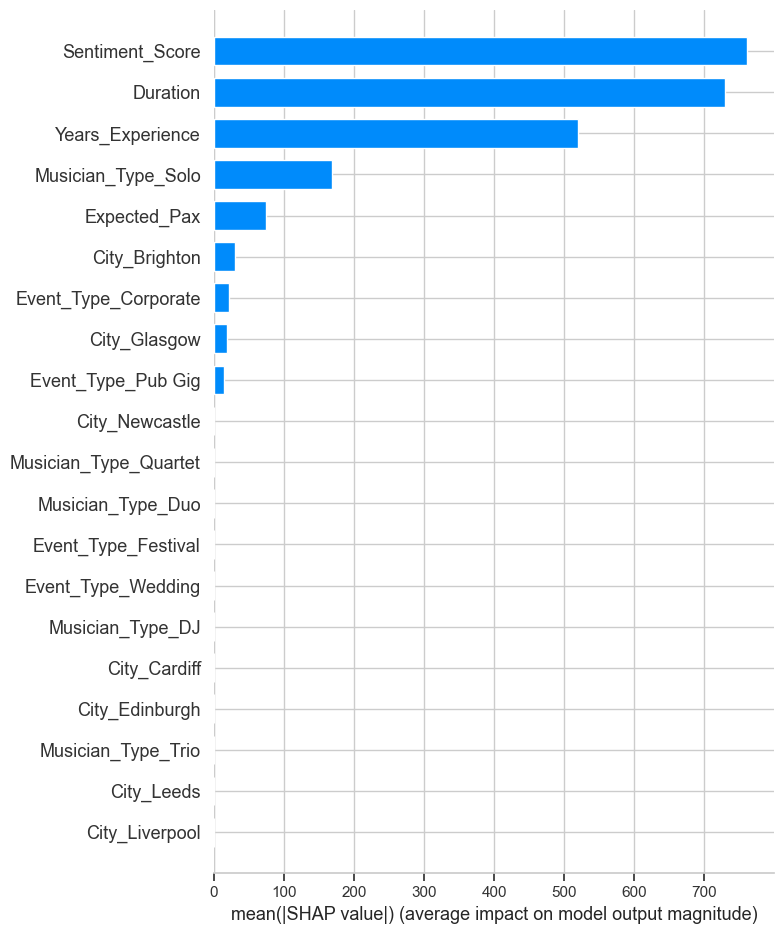

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb
import shap
import pandas as pd
import numpy as np

# PREPARE THE DATA FOR PRICING
pricing_df = master_df.copy()

pricing_df = pricing_df.dropna(subset=['Price_Charged'])

# Select features that influence price
features = ['Expected_Pax', 'Duration', 'Years_Experience', 'Event_Type', 'City', 'Musician_Type']
target = 'Price_Charged'

X = pd.get_dummies(pricing_df[features], drop_first=True)
y = pricing_df[target]

sentiment_mapping = musicians_df.set_index('Musician_ID')['BERT_Score'].to_dict()
X['Sentiment_Score'] = pricing_df['Musician_ID'].map(sentiment_mapping).fillna(0.0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# BASELINE MODEL: LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
print(f"Linear Regression RMSE: £{lr_rmse:.2f}")
print(f"Linear Regression MAE: £{lr_mae:.2f}")


# ADVANCED MODEL: LIGHTGBM
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mae = mean_absolute_error(y_test, lgb_preds)
print(f"\nLightGBM RMSE: £{lgb_rmse:.2f}")
print(f"LightGBM MAE: £{lgb_mae:.2f}")


# -EXPLAINABLE AI: SHAP ANALYSIS
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

print("\nGenerating SHAP Explainability Plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar")

#### Evaluation

In [38]:
# RMSE & MAE
print("Linear Regression RMSE:", round(lr_rmse,2))
print("Linear Regression MAE:", round(lr_mae,2))

print("\nLightGBM RMSE:", round(lgb_rmse,2))
print("LightGBM MAE:", round(lgb_mae,2))

Linear Regression RMSE: 1175.35
Linear Regression MAE: 933.75

LightGBM RMSE: 752.97
LightGBM MAE: 510.31


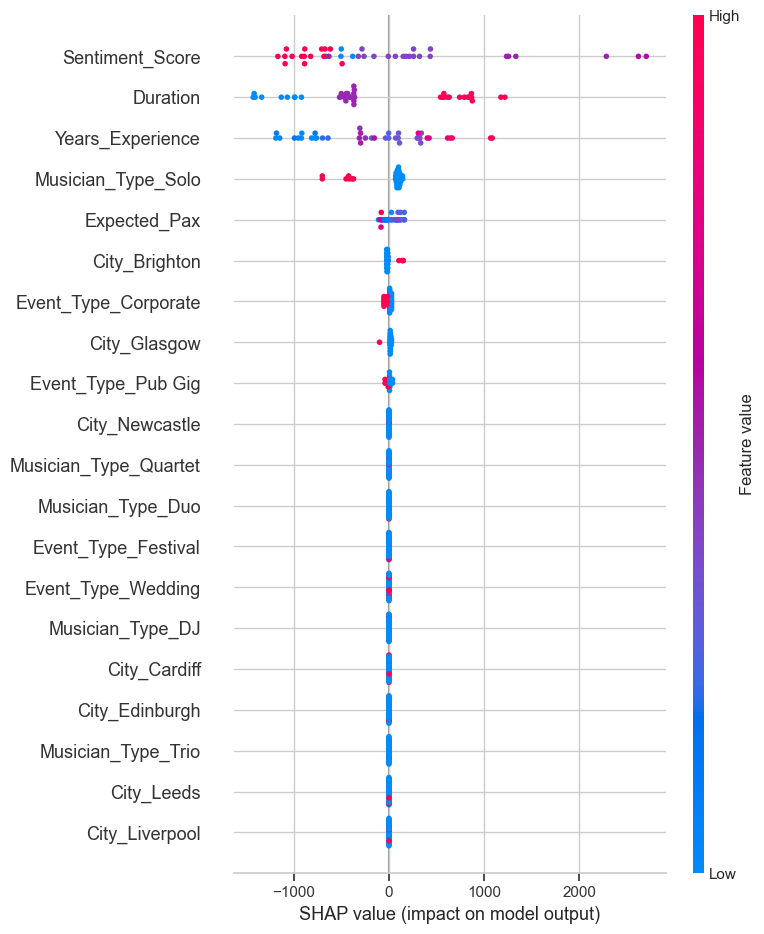

In [39]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

#### Export Models

In [13]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

print("Saving models to disk...")

# 1. Save the Recommendation Engine Components
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.joblib')
joblib.dump(musician_matrix, 'saved_models/musician_tfidf_matrix.joblib')
joblib.dump(svd, 'saved_models/cf_svd_model.joblib')
joblib.dump(user_item_matrix, 'saved_models/user_item_matrix.joblib')
joblib.dump(predicted_ratings_df, 'saved_models/predicted_ratings_df.joblib')

# 2. Save the Dynamic Pricing Model (LightGBM)
joblib.dump(lgb_model, 'saved_models/lightgbm_pricing_model.joblib')

# 3. Save the Anomaly Detection Model (Isolation Forest)
joblib.dump(iso_forest, 'saved_models/isolation_forest_model.joblib')

# 4. Save the processed dataframes so the API knows who the musicians are!
musicians_df.to_pickle('saved_models/musicians_processed.pkl')

print("All models successfully saved in the 'saved_models' folder!")

Saving models to disk...
All models successfully saved in the 'saved_models' folder!
